In [3]:
import json
import re
import pandas as pd
from pathlib import Path
from tqdm import tqdm

def extract_date_info(filename):
    """Extract week and year from filename like 'd23sn2021.pdf'"""
    match = re.match(r'd(\d+)sn(\d{4})\.pdf', filename)
    if match:
        week_num = int(match.group(1))
        year = int(match.group(2))
        return year, week_num
    return None, None

In [ ]:
# This notebook lives in fom_events/. Work out that folder from where Jupyter was
# started, so the paths hold wherever the project is checked out.
HERE = Path.cwd() if Path.cwd().name == "fom_events" else Path.cwd() / "fom_events"

input_file = HERE / "processed_events" / "processed_events.json"

# Output files
csv_output = HERE / "processed_events" / "events_table.csv"

# Load the processed events data
with open(input_file, 'r', encoding='utf-8') as f:
    data = json.load(f)

# Create a list to store all events
all_events = []

# Process each file's data
for filename, events in tqdm(data.items()):
    year, week = extract_date_info(filename)
    
    if year is None or week is None:
        print(f"Skipping {filename} - couldn't extract date information")
        continue
    
    # Format as "YYYY-WW" (year and week)
    date_str = f"{year}-{week:02d}"
    
    # Process each event in the file
    for i, event in enumerate(events):
        # Debug information
        if not isinstance(event, dict):
            print(f"\nProblem in file: {filename}")
            print(f"Event index: {i}")
            print(f"Event type: {type(event)}")
            print(f"Event content: {event[:100] if isinstance(event, str) else event}")
            print(f"Parent events type: {type(events)}")
            print(f"Sample of events: {str(events)[:200]}...")
            
            # Try to continue with a default empty dict instead of skipping
            event = {}
        
        # Extract event details
        event_name = event.get("название", "")
        description = event.get("цитаты", "")
        
        # Handle percentage which might be a string or a number
        percentage_raw = event.get("процент", "")
        
        # Convert percentage to float if possible
        try:
            if percentage_raw is None:
                percentage = None
            elif isinstance(percentage_raw, (int, float)):
                percentage = float(percentage_raw)
            else:
                percentage = float(percentage_raw.replace("%", "").strip())
        except (ValueError, AttributeError):
            percentage = None
        
        # Add to our list of events
        all_events.append({
            "date": date_str,
            "year": year,
            "week": week,
            "event": event_name,
            "description": description,
            "percentage": percentage
        })

# Convert to DataFrame
df = pd.DataFrame(all_events)

# Sort by date (year and week) and then by percentage (descending)
df = df.sort_values(by=["year", "week", "percentage"], ascending=[True, True, False])

# Save as CSV
df.to_csv(csv_output, index=False, encoding='utf-8')

print(f"Data organized and saved to {csv_output}")

In [9]:
df

,date,year,week,event,description,percentage
15,2020-02,2020,2,"Затрудняюсь ответить, нет ответа",[],52.0
0,2020-02,2020,2,Гибель украинского самолета над Ираном,"[«Катастрофа украинского лайнера в Иране», «сб...",20.0
1,2020-02,2020,2,"Обмен ударами между США и Ираном, сложная ситу...","[«Иран, США, Сирия, Ливия – события там», «США...",17.0
2,2020-02,2020,2,Пожары в Австралии,"[«Австралия горит», «массовые пожары в Австрал...",3.0
3,2020-02,2020,2,"Празднование Нового года, Рождества","[«Новогодние праздники», «Рождество», «фестива...",2.0
...,...,...,...,...,...,...
3681,2025-11,2025,11,Высказывания и действия В. Путина,"[«Приезд Путина в Курскую область», «Путин всё...",1.0
3682,2025-11,2025,11,"Рост цен, тарифов","[«Всё дорожает», «повышение цен», «рост цен», ...",1.0
3683,2025-11,2025,11,Встреча В. Путина и А. Лукашенко,"[«Встреча Путина и Лукашенко», «президент Бело...",1.0
3684,2025-11,2025,11,Другие события в России,"[«Масленица», «пост начался», «лыжные гонки, ч...",1.0


In [10]:
df.description.isna().sum()

1

In [15]:
df.to_clipboard()

In [11]:
# Filter out rows where the event contains 'Затрудняюсь ответить'
df = df[~df['event'].str.contains('Затрудняюсь ответить', na=False)]
df.shape

(3490, 6)

<Axes: >

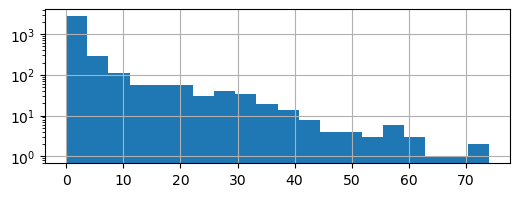

In [12]:
df.percentage.hist(log=True, bins=20, figsize=(6, 2))

In [14]:
df[df.percentage >= 2].to_clipboard()